<a href="https://colab.research.google.com/github/superpoupette/data-tab/blob/main/notebooks/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!git clone https://github.com/superpoupette/data-tab.git

fatal: destination path 'data-tab' already exists and is not an empty directory.


In [39]:
!git pull

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 8 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 102.03 KiB | 2.13 MiB/s, done.
From https://github.com/superpoupette/data-tab
   90183a0..ab76da3  main       -> origin/main
Updating 90183a0..ab76da3
Fast-forward
 notebooks/01_exploration.ipynb | 405 +++++++++++++++++++++++++++++++++++++----
 scripts/importation_hevy.py    |  10 +-
 2 files changed, 375 insertions(+), 40 deletions(-)


In [40]:
import importlib
import scripts.importation_hevy as ih

importlib.reload(ih)

<module 'scripts.importation_hevy' from '/content/data-tab/scripts/importation_hevy.py'>

In [41]:
from scripts.importation_hevy import prepare_data

In [42]:
workouts, sessions = prepare_data(
    "data/workouts.csv",
    "data/exercices.csv"
)

In [43]:
sessions.head()

,start_time,end_time,nombre_series,nombre_exercices,volume_total,exercices,muscles,mois,duree_minutes
0,2026-04-22 07:02:00,2026-04-22 07:46:00,15,5,7470.0,"Leg Press Horizontal (Machine), Abductor, Hip ...",,2026-04,44.0
1,2026-04-26 09:08:00,2026-04-26 10:29:00,21,8,2568.5,"Vertical Traction (Machine), Lat Pulldown (Cab...","Dos, Épaules, Bras, Abdominaux",2026-04,81.0
2,2026-04-28 07:02:00,2026-04-28 07:57:00,18,6,7455.0,"Hip Thrust (Barbell), Hip Adduction (Machine),...",,2026-04,55.0
3,2026-04-29 06:59:00,2026-04-29 07:59:00,17,6,3700.0,"Pull Up (Assisted), Vertical Traction (Machine...",Dos,2026-04,60.0
4,2026-05-04 06:59:00,2026-05-04 08:04:00,19,7,7670.0,"Hip Thrust (Barbell), Hip Adduction (Machine),...",,2026-05,65.0


In [36]:
workouts.head()

,title,start_time,end_time,description,exercise_title,superset_id,exercise_notes,set_index,set_type,weight_kg,reps,distance_km,duration_seconds,rpe,volume,muscle
0,Les gros pecs là 🫦,2026-07-01 06:57:00,2026-07-01 08:02:00,NaN,Pull Up (Assisted),NaN,NaN,0,normal,35.0,10.0,NaN,NaN,NaN,350.0,Dos
1,Les gros pecs là 🫦,2026-07-01 06:57:00,2026-07-01 08:02:00,NaN,Pull Up (Assisted),NaN,NaN,1,normal,28.0,4.0,NaN,NaN,NaN,112.0,Dos
2,Les gros pecs là 🫦,2026-07-01 06:57:00,2026-07-01 08:02:00,NaN,Pull Up (Assisted),NaN,NaN,2,dropset,35.0,6.0,NaN,NaN,NaN,210.0,Dos
3,Les gros pecs là 🫦,2026-07-01 06:57:00,2026-07-01 08:02:00,NaN,Pull Up (Assisted),NaN,NaN,3,normal,28.0,5.0,NaN,NaN,NaN,140.0,Dos
4,Les gros pecs là 🫦,2026-07-01 06:57:00,2026-07-01 08:02:00,NaN,Pull Up (Assisted),NaN,NaN,4,dropset,35.0,5.0,NaN,NaN,NaN,175.0,Dos


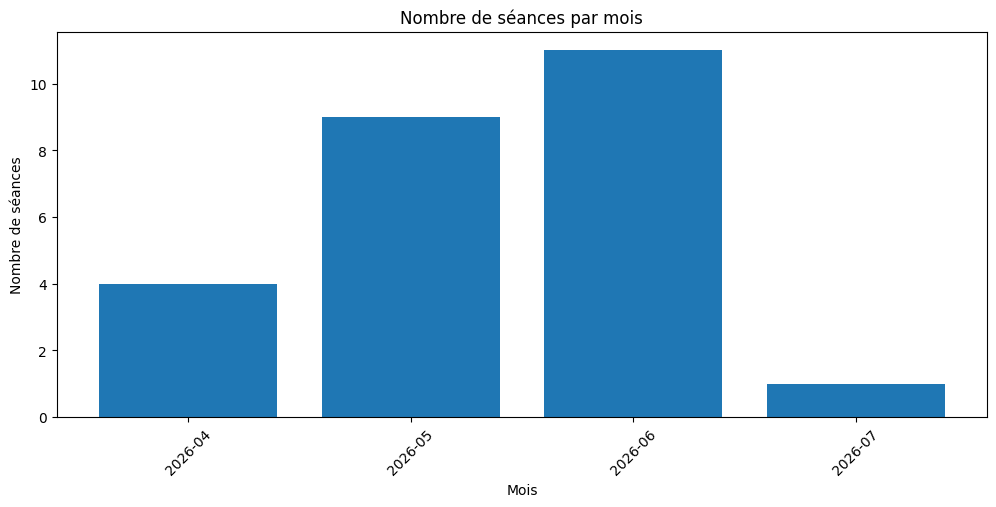

In [21]:
import matplotlib.pyplot as plt

# Compter le nombre de séances par mois
sessions_par_mois = sessions.groupby("mois").size()

# Création du graphique
plt.figure(figsize=(12, 5))

plt.bar(
    sessions_par_mois.index.astype(str),
    sessions_par_mois.values
)

plt.xlabel("Mois")
plt.ylabel("Nombre de séances")
plt.title("Nombre de séances par mois")

plt.xticks(rotation=45)

plt.show()

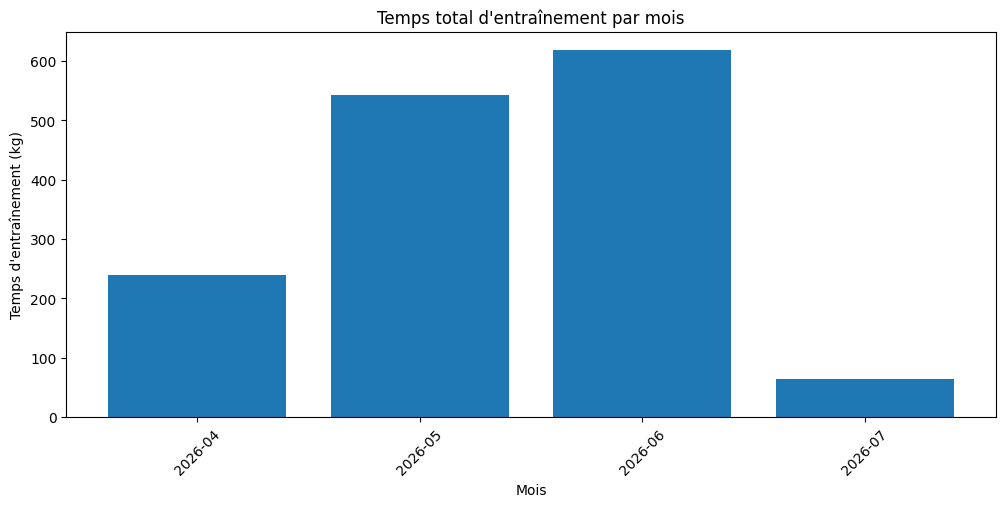

In [24]:
import matplotlib.pyplot as plt

# Somme du temps d'entraînement par mois
temps_par_mois = sessions.groupby("mois")["duree_minutes"].sum()

# Création du graphique
plt.figure(figsize=(12, 5))

plt.bar(
    temps_par_mois.index.astype(str),
    temps_par_mois.values
)

plt.xlabel("Mois")
plt.ylabel("Temps d'entraînement (minutes)")
plt.title("Temps total d'entraînement par mois")

plt.xticks(rotation=45)

plt.show()

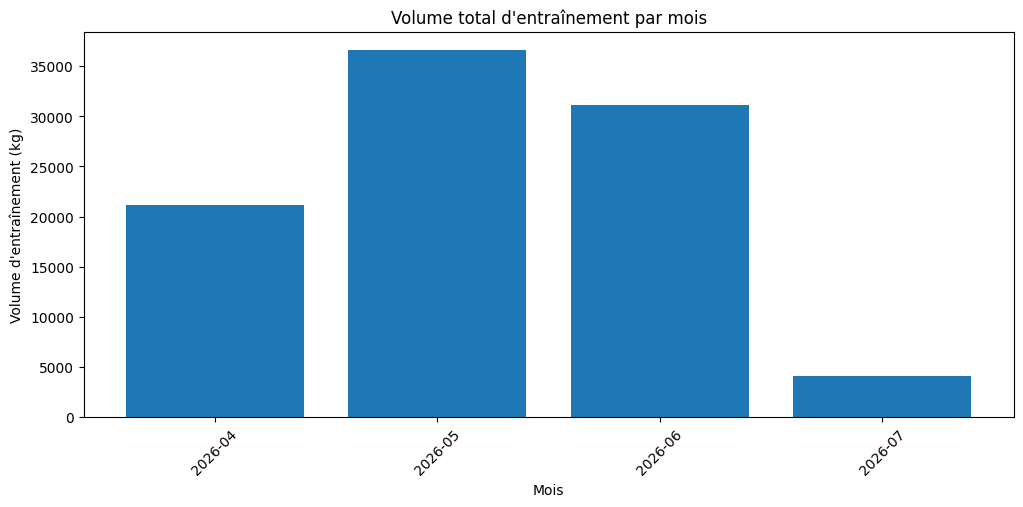

In [26]:
import matplotlib.pyplot as plt

# Somme du temps du volume par mois
volume_par_mois = sessions.groupby("mois")["volume_total"].sum()

# Création du graphique
plt.figure(figsize=(12, 5))

plt.bar(
    volume_par_mois.index.astype(str),
    volume_par_mois.values
)

plt.xlabel("Mois")
plt.ylabel("Volume d'entraînement (kg)")
plt.title("Volume total d'entraînement par mois")

plt.xticks(rotation=45)

plt.show()

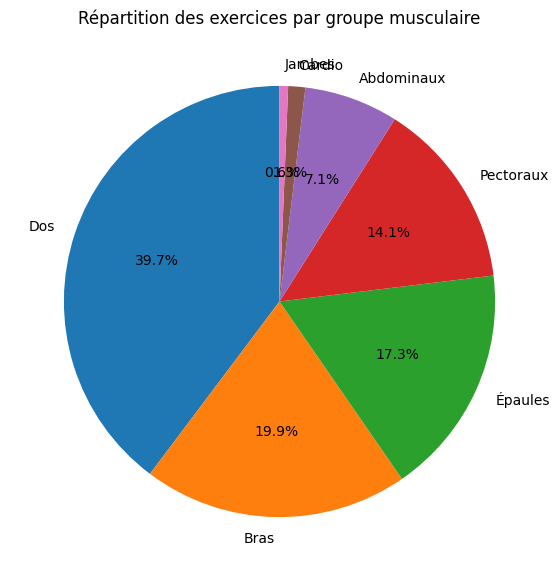

In [37]:
import matplotlib.pyplot as plt

# Nombre d'exercices par groupe musculaire
repartition = workouts["muscle"].value_counts()

# Diagramme en camembert
plt.figure(figsize=(7, 7))

plt.pie(
    repartition,
    labels=repartition.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des exercices par groupe musculaire")

plt.show()

In [44]:
print(f"Nombre total de séances : {len(sessions)}")

print(f"Temps total : {sessions['duree_minutes'].sum()/60:.1f} h")

print(f"Volume total : {workouts['volume'].sum()/1000:.1f} tonnes")

print(f"Exercices différents : {workouts['exercise_title'].nunique()}")

print(f"Durée moyenne : {sessions['duree_minutes'].mean():.0f} min")

Nombre total de séances : 25
Temps total : 24.4 h
Volume total : 93.0 tonnes
Exercices différents : 42
Durée moyenne : 59 min
